# GPT-Style Text Generation
## AIAT 122 – Deep Learning

## Learning objectives
- Load a pre-trained GPT-style model and generate text from prompts.
- Control generation with temperature and sampling (top-k, top-p).
- Compare different settings and see sample outputs.

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 05 "GPT Text Generation: Local GPT-2 and the OpenAI API" — the same model; here the focus narrows to the sampling controls.

**Used later in:** Course 10 (AIAT 124) — Unit 2, lesson 01 "Text Generation with Autoregressive (GPT-style) Models".

---

**Where is this used in real life?** GPT-style models power chatbots (e.g. ChatGPT), code completion (e.g. GitHub Copilot), and content creation. **We use a decoder-only Transformer (GPT) to generate coherent text from a prompt. We use it instead of RNNs or n-gram models because** it captures long-range context and produces fluent, context-aware text; RNNs are slower and forget long context, and n-grams don’t model meaning.

**Prerequisites:** Python 3.8+, basics of transformers/attention. Before starting: run the imports cell; if `transformers` or `torch` fails, install with `pip install transformers torch` and restart the kernel.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Short theory
- **GPT** = Generative Pre-trained Transformer: decoder-only Transformer trained to predict the next token.
- **Text generation:** Given a prompt, the model autoregressively samples the next token; we decode to get text.
- **Temperature:** Higher (e.g. 0.9) → more diverse/creative; lower (e.g. 0.5) → more focused/deterministic.
- **top-k / top-p:** Limit sampling to top-k tokens or nucleus (top-p) to reduce nonsense.
- **Data flow:** prompt → tokenize → model forward (causal attention) → sample next token → append → repeat until max_length or EOS.

## Inputs & Outputs
**Inputs:** Hugging Face `transformers` and `torch`, pre-trained GPT-2 (`gpt2`), and text prompts.  
**Outputs:** Loaded model info, generated text for sample prompts, and a comparison of different temperature settings (printed). Run time: under ~10 min (model download once; generation is fast).


In [1]:
%pip install transformers torch datasets -q



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# WHAT: imports for running GPT-2 through Hugging Face Transformers (PyTorch backend only).
# WHY: USE_TF=0 avoids TensorFlow/Keras version clashes; warnings are silenced to keep output readable.
import os
os.environ["USE_TF"] = "0"  # PyTorch only; avoid Keras 3 / TF conflict
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import warnings
warnings.filterwarnings("ignore")
print("✅ Setup complete!")

✅ Setup complete!


### Step 1: Load GPT-2 (pre-trained decoder-only Transformer)


In [3]:
# Load pre-trained GPT-2 (small model). If download fails (e.g. no internet), use a tiny local model so the notebook still runs.
from transformers import GPT2Config

# The tokenizer maps text to token IDs; GPT-2 has no pad token, so we reuse end-of-text.
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

try:
    # Prefer cache to avoid re-download; then try download
    model = GPT2LMHeadModel.from_pretrained("gpt2", local_files_only=True)
except (OSError, ValueError):
    try:
        model = GPT2LMHeadModel.from_pretrained("gpt2")
    except (OSError, EnvironmentError) as e:
        print("⚠️ Could not download GPT-2 (network error). Using a tiny GPT-2-style model so you can run the rest of the notebook.")
        print("   For real GPT-2, check your internet and run this cell again.\n")
        # Tiny fallback config (4 layers) - untrained, but it lets every later cell run offline.
        config = GPT2Config(
            vocab_size=tokenizer.vocab_size,
            n_positions=128,
            n_embd=256,
            n_layer=4,
            n_head=4,
        )
        model = GPT2LMHeadModel(config)

# Report model size and context window so students know what they loaded.
print(f"Model parameters: {model.num_parameters():,}")
print(f"Vocabulary size: {len(tokenizer)} tokens")
print(f"Max context length: {model.config.n_positions} tokens")
print("\n✅ GPT-2 model loaded!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model parameters: 124,439,808
Vocabulary size: 50257 tokens
Max context length: 1024 tokens

✅ GPT-2 model loaded!


### Step 2: Define generation function and run one example


In [4]:
# We use GPT here (decoder-only Transformer) for autoregressive text generation; order and context matter.
def generate_text(prompt, model, tokenizer, max_length=80, temperature=0.7, top_k=50, top_p=0.9):
    """Generate text from prompt using temperature and top-k/top-p sampling."""
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(
        inputs["input_ids"],
        max_new_tokens=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# One example
prompt = "The future of artificial intelligence"
out = generate_text(prompt, model, tokenizer, max_length=60, temperature=0.7)
print("Prompt:", prompt)
print("Generated:", out[:400] + "..." if len(out) > 400 else out)
print("\n✅ Generation works!")


Prompt: The future of artificial intelligence
Generated: The future of artificial intelligence and computer vision will be more complex than we've ever imagined," said Dr. John Stirling, professor of computer vision at MIT.

"When you combine the two, it becomes much more difficult to predict, and more difficult to predict, the future of our world," he added.


✅ Generation works!


### Step 3: Generate from several prompts (e.g. content-creation style)


In [5]:
# Real-world scenario: short content prompts (marketing / blog style)
prompts = [
    "The impact of artificial intelligence on healthcare",
    "How to get started with machine learning",
]
# Generate up to 50 tokens per prompt; temperature 0.7 is mildly creative but mostly coherent.
for p in prompts:
    text = generate_text(p, model, tokenizer, max_length=50, temperature=0.7)
    print(f"Prompt: {p}")
    print(f"Generated: {text[:300]}...")
    print("-" * 50)

Prompt: The impact of artificial intelligence on healthcare
Generated: The impact of artificial intelligence on healthcare is complex, and we have little idea what the effects will be. But here are the things we know about artificial intelligence and the future of healthcare.

The Future of Healthcare

The next stage of the healthcare revolution is the next step in...
--------------------------------------------------


Prompt: How to get started with machine learning
Generated: How to get started with machine learning in Scala

First, let's start by building a machine learning framework.

Let's start with Scala's standard library and try to get started with the code.

The first thing to do is create a new file called module....
--------------------------------------------------


### Step 4: What temperature actually does

The previous cells changed a number and looked at the words that came out. That is the wrong way round: temperature is a **transformation of the next-token probability distribution**, and you can look at that distribution directly.

At every step GPT-2 produces one score (a logit) per token in its 50,257-token vocabulary. Sampling divides those logits by the temperature *T* before the softmax:

$$P_T(\text{token}) = \frac{\exp(z_{\text{token}}/T)}{\sum_j \exp(z_j/T)}$$

Dividing by a small *T* stretches the gaps between logits, so the leader runs away with the probability mass. Dividing by a large *T* squashes them together. The cell below computes that distribution for one real prompt, plots it, and then measures whether the generated text behaves the way the distribution says it should.

T = 0.3:  P(top token '␣is') = 0.952   entropy = 0.26 nats   top-p=0.9 nucleus = 1 tokens
T = 0.7:  P(top token '␣is') = 0.519   entropy = 2.11 nats   top-p=0.9 nucleus = 11 tokens
T = 1.0:  P(top token '␣is') = 0.258   entropy = 3.93 nats   top-p=0.9 nucleus = 122 tokens
T = 0.3: 200 draws of the next token produced 1 distinct tokens (after top-k=50 and top-p=0.9)
T = 0.7: 200 draws of the next token produced 10 distinct tokens (after top-k=50 and top-p=0.9)
T = 1.0: 200 draws of the next token produced 22 distinct tokens (after top-k=50 and top-p=0.9)

One generated sample at each temperature, for the words themselves:


  T=0.3: The impact of artificial intelligence on healthcare is already being felt in the United States, where the number of people with mental health problems has increased by mo...


  T=0.7: The impact of artificial intelligence on healthcare is already clear. A recent study from the University of California, San Francisco, found that the number of US adults ...


  T=1.0: The impact of artificial intelligence on healthcare is being measured with our own eyes, we all have to accept it, but for the majority of people it does nothing to chang...

Honest note: we also measured repetition inside those short samples. At 40 tokens and
three seeds that measure is dominated by noise and does NOT separate the temperatures -
so it is not plotted. The distribution and the draw counts above are exact; a text-level
diversity claim would need hundreds of samples. Measure at the level where the effect is.


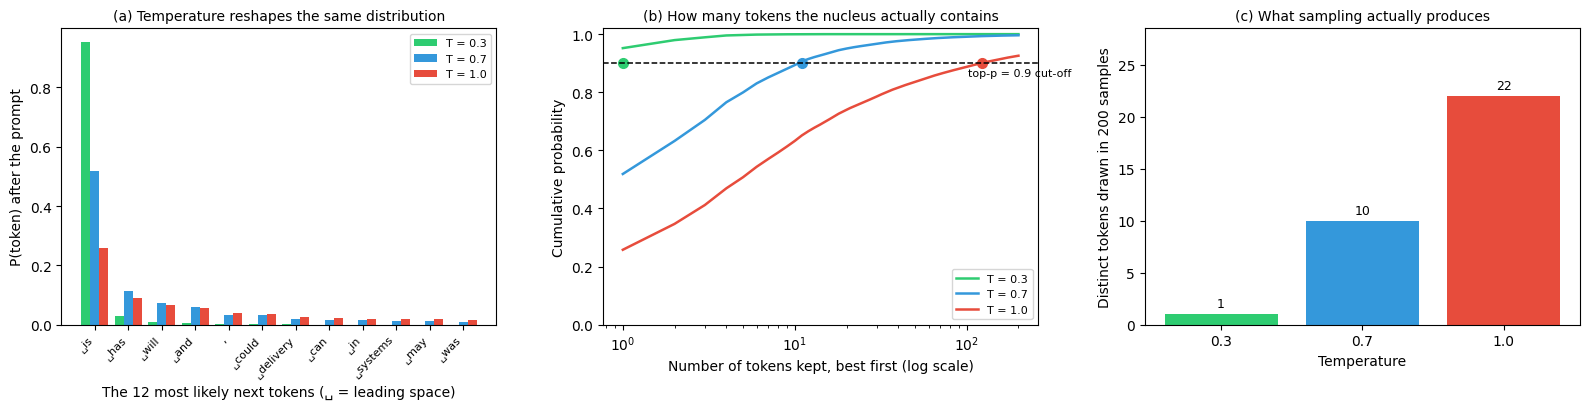

In [6]:
# WHAT: read GPT-2's next-token distribution for one prompt, reshape it at three temperatures,
#       and then measure the diversity of text actually generated at each.
# WHY: "higher temperature = more diverse" is a claim about a distribution. Plot the distribution,
#      then check that the generated text agrees. Do not plot the length of the output -
#      max_new_tokens fixes that, so it measures nothing.
import matplotlib.pyplot as plt
import numpy as np

prompt = "The impact of artificial intelligence on healthcare"
temps = [0.3, 0.7, 1.0]
colours = ["#2ecc71", "#3498db", "#e74c3c"]

# ── 1. The distribution itself, straight out of the model ────────────────────
enc = tokenizer(prompt, return_tensors="pt")
with torch.no_grad():
    logits = model(**enc).logits[0, -1]        # scores for the NEXT token, all 50,257 of them
order = torch.argsort(logits, descending=True) # temperature cannot change this ranking
labels = [tokenizer.decode([int(i)]).replace(" ", "\u2423") for i in order[:12]]

dists, nucleus = {}, {}
for T in temps:
    pT = torch.softmax(logits / T, dim=-1)[order]
    dists[T] = pT.numpy()
    nucleus[T] = int((np.cumsum(dists[T]) < 0.9).sum() + 1)   # size of the top-p = 0.9 nucleus
    ent = float(-(pT * torch.log(pT + 1e-12)).sum())
    print(f"T = {T}:  P(top token '{labels[0]}') = {dists[T][0]:.3f}   "
          f"entropy = {ent:.2f} nats   top-p=0.9 nucleus = {nucleus[T]:,} tokens")

# ── 2. What sampling actually draws, at each temperature ────────────────────
# Apply the SAME top-k / top-p filter generate_text uses, then draw the first token 200 times
# and count how many distinct tokens come out. 200 draws costs nothing (no model call) and,
# unlike three 40-token samples, it has enough power to separate the temperatures.
N_DRAWS = 200
rng = np.random.default_rng(0)
distinct = []
for T in temps:
    pf = dists[T].copy()
    pf[50:] = 0.0                                  # top_k = 50
    c = np.cumsum(pf / pf.sum())
    pf[int((c < 0.9).sum() + 1):] = 0.0            # top_p = 0.9 nucleus
    pf = pf / pf.sum()
    draws = rng.choice(len(pf), size=N_DRAWS, p=pf)
    distinct.append(len(set(draws.tolist())))
    print(f"T = {T}: {N_DRAWS} draws of the next token produced {distinct[-1]} distinct tokens "
          f"(after top-k=50 and top-p=0.9)")

print("\nOne generated sample at each temperature, for the words themselves:")
for T in temps:
    torch.manual_seed(0)
    out = generate_text(prompt, model, tokenizer, max_length=40, temperature=T)
    print(f"  T={T}: {out[:170]}...")
print("\nHonest note: we also measured repetition inside those short samples. At 40 tokens and")
print("three seeds that measure is dominated by noise and does NOT separate the temperatures -")
print("so it is not plotted. The distribution and the draw counts above are exact; a text-level")
print("diversity claim would need hundreds of samples. Measure at the level where the effect is.")

# ── 3. The figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

x = np.arange(len(labels)); w = 0.27
for k, (T, col) in enumerate(zip(temps, colours)):
    axes[0].bar(x + (k - 1) * w, dists[T][:12], width=w, color=col, label=f"T = {T}")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("The 12 most likely next tokens (\u2423 = leading space)")
axes[0].set_ylabel("P(token) after the prompt")
axes[0].set_title("(a) Temperature reshapes the same distribution", fontsize=10)
axes[0].legend(fontsize=8)

for T, col in zip(temps, colours):
    axes[1].plot(np.arange(1, 201), np.cumsum(dists[T])[:200], color=col, lw=1.8, label=f"T = {T}")
    axes[1].plot([nucleus[T]], [0.9], "o", color=col, ms=7)
axes[1].axhline(0.9, color="black", ls="--", lw=1.1)
axes[1].text(102, 0.855, "top-p = 0.9 cut-off", fontsize=8)
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of tokens kept, best first (log scale)")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("(b) How many tokens the nucleus actually contains", fontsize=10)
axes[1].legend(fontsize=8, loc="lower right")

bars = axes[2].bar([str(t) for t in temps], distinct, color=colours)
axes[2].bar_label(bars, fmt="%d", fontsize=9, padding=3)
axes[2].set_xlabel("Temperature")
axes[2].set_ylabel(f"Distinct tokens drawn in {N_DRAWS} samples")
axes[2].set_ylim(0, max(distinct) * 1.25 + 1)
axes[2].set_title("(c) What sampling actually produces", fontsize=10)
plt.tight_layout(); plt.show()

### 👁️ Read the figure

- **(a)** The **same twelve candidate tokens**, three temperatures. Temperature cannot change the *ranking* — it divides every logit by the same number — so the only thing that moves is how the mass is shared. At **T = 0.3** the green bar on the leading token towers over everything else; sampling will pick it almost every time, which is why low-temperature text is safe and repetitive. At **T = 1.0** the red bars are far more even and several continuations get a real chance. That is the entire mechanism, in one picture.
- **(b)** The same three distributions read cumulatively, best token first, on a log x-axis. The dot on each curve is where it crosses **top-p = 0.9** — the nucleus. The printed line gives the exact sizes, and they are dramatic: at T = 0.3 the nucleus is a *single token*, at T = 0.7 about a dozen, at T = 1.0 over a hundred. **`top_p` and `temperature` are not independent knobs**: turning one changes what the other does.
- **(c)** The consequence, measured. Drawing the next token 200 times through the real top-k = 50 / top-p = 0.9 filter, low temperature returns almost the same token every time while high temperature returns many different ones. This is what "more diverse" means, counted rather than asserted.
- **What this figure replaced, and why.** The earlier version of this cell plotted *generated length* against temperature. Length is fixed by `max_new_tokens`, so that chart measured nothing and the sentence under it could not be true. We also tried measuring repetition inside three 40-token samples: at that sample size the numbers do not separate the temperatures, so they are printed with that caveat and not drawn. **Plot the level at which the effect actually lives.**

### Step 5: Fine-tuning concept (no training here; run time stays short)
In real life, companies fine-tune GPT for domain-specific content (legal, medical) or brand voice. Full fine-tuning needs more data and GPU time; here we only show the idea.

In [7]:
# Conceptual example: Fine-tuning setup
# In production, you would:
# 1. Prepare domain-specific dataset
# 2. Configure training arguments
# 3. Fine-tune model
# 4. Evaluate on test set

print("📚 Fine-tuning Concept:")
print("\n1. Prepare Dataset:")
print(" - Collect domain-specific text (e.g., medical articles)")
print(" - Format as text files or use Hugging Face datasets")
print("\n2. Configure Training:")
print(" - Learning rate: 5e-5")
print(" - Batch size: 4-8 (depending on GPU)")
print(" - Epochs: 3-5")
print("\n3. Fine-tune Model:")
print(" - Use Trainer API from transformers")
print(" - Monitor loss and perplexity")
print("\n4. Evaluate:")
print(" - Test on held-out data")
print(" - Compare with base model")
print("\n✅ Fine-tuning process understood!")

📚 Fine-tuning Concept:

1. Prepare Dataset:
 - Collect domain-specific text (e.g., medical articles)
 - Format as text files or use Hugging Face datasets

2. Configure Training:
 - Learning rate: 5e-5
 - Batch size: 4-8 (depending on GPU)
 - Epochs: 3-5

3. Fine-tune Model:
 - Use Trainer API from transformers
 - Monitor loss and perplexity

4. Evaluate:
 - Test on held-out data
 - Compare with base model

✅ Fine-tuning process understood!


## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot launched in June 2021 "powered by OpenAI Codex" (GitHub blog, 29 June 2021). It has since moved to a choice of models, and GitHub does not publish which one answers any given request — so do not attach a model name to it from memory.
- Models in this family emit one **token** at a time, conditioned on everything before it. Not one character, and not a whole line at once.
- Autocomplete on your phone is a much smaller version of the same next-symbol loop.

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [8]:
# WHAT: train a character-level LSTM language model on a Shakespeare passage, then sample new text.
# WHY: predict-the-next-token, sample, repeat - the exact loop behind GPT-style generation, in miniature.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# Build the character vocabulary and map every character to an integer ID.
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

# Training pairs: 20 characters of context -> the character that follows.
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
# The model: embed characters, run a 2-layer LSTM, predict the next character from the last hidden state.
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# 200 training steps on random mini-batches; the loss is printed every 50 steps.
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
# Generation: feed the context, sample the next character from the softmax, append it, repeat.
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            # Temperature rescales the logits: lower = safer and more repetitive, higher = more random.
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notle e he to die to sleep no more and by a sleep to say we end the heartache and the thousand natural 

This is exactly how ChatGPT generates text — one token at a time.


## 💬 Discuss

1. At **T = 0.3** the top-p = 0.9 nucleus is a **single token** and 200 draws produced **1** distinct token; at **T = 1.0** the nucleus is **122** tokens and 200 draws produced **22**. So `top_p` and `temperature` are not independent knobs. If a product team hands you one slider labelled "creativity", what does it actually change — and would you ship one slider or two? Defend the version that is harder for you to explain.
2. The very first generated sample in this notebook attributes a quotation to "Dr. John Stirling, professor of computer vision at MIT" — fluent, correctly formatted, and unverified. Work through **each** of temperature, top-k and top-p and say which of them would have prevented it. Then say what actually would.
3. The character-level model at the end reaches a training loss of **0.011** and emits text that is nearly a verbatim stretch of its own training passage. Is that a language model or a lookup table? Write the test that separates them, and say what loss value you would have *expected* from a model that had genuinely learned something.


## ⚠️ Where this breaks

- **Fluency is not accuracy, and this notebook's own output is the exhibit.** The Step 2 sample attributes a quotation to a named professor at a named university. None of the sampling controls touches truth: they reshape a distribution over tokens, and a confident falsehood and a confident fact have exactly the same shape.
- **A loss of 0.011 on roughly 300 characters is memorisation, not learning.** The character model's corpus is one Shakespeare passage and there is no held-out text anywhere, so the loss can only fall and the generated string is largely the training text played back. Notebook `08` shows the same effect from the inside: the top candidate holds **0.86–0.94** of the probability at every step, which is what a memorised model looks like.
- **The temperature measurements are exact at the level they were taken and nowhere else.** The distributions, the nucleus sizes (**1 / 11 / 122**) and the 200-draw counts (**1 / 10 / 22**) are for *one prompt* at *one position*. The notebook is explicit that a text-level diversity claim at 40 tokens and three seeds does not separate the temperatures, so it is printed with that caveat and not drawn.
- **Plot the level at which the effect actually lives.** Output length is fixed by `max_new_tokens`, so a length-versus-temperature chart measures nothing at all. When you see one in a tutorial, that is the tell.
- **A tuned temperature does not transfer.** Move `top_k` or `top_p` and the same `temperature` is a different setting. Record all three or record none.
- **The assumption that must hold:** somebody downstream checks the output. A system that answers on every input with no mechanism to abstain will eventually answer confidently on the one input where it should have refused. **Zillow Offers** is that property costing real money: the model produced a price for every house, Zillow bought on it, the programme was wound down on **2 November 2021**, Q3 2021 carried a **$304.4 million** inventory write-down and roughly **25%** of the workforce went with it.
- **Cheaper alternative:** if the answer must be one of a known set — a category, a field, a template — constrain the decode or use a classifier. Free-form generation is the most expensive way to produce an answer you could have enumerated, and the only way to produce one you cannot check.


## 🧩 Mini-exercise

**Try it:** Change the temperature (e.g. 0.7 → 0.3 or 1.0) and generate again from the same prompt. How does the output change? Or try a different prompt.

---

## Summary
**What you did**
- Loaded pre-trained GPT-2 and generated text from prompts.
- Used a `generate_text` helper with temperature and top-k/top-p.
- Compared different temperatures, and saw why a length-vs-temperature plot is the wrong
  measurement here: `max_new_tokens` fixes the length, so temperature changes *which* tokens
  appear, not how many.

**In real life you'd also:** Fine-tune on domain data, use larger models (e.g. via API), add safety filters, and deploy with batching and caching.

**The main idea:** GPT-style models generate text autoregressively; temperature and sampling controls trade off coherence vs diversity.

**Next:** `08_text_generation_rnn_lstm_gru.ipynb` shows RNN/LSTM/GRU-based text generation for comparison with Transformer-based GPT.

## 🔭 State of the field (2026)

Temperature, top-k and top-p are still the controls, and the decode loop you ran is still the loop. What changed is what happens *inside* it. Since DeepSeek-R1 (arXiv 2501.12948) it is routine to train a model with reinforcement learning from verifiable rewards so that it emits a long deliberate reasoning passage before answering, and open families now ship that as a **switchable mode** rather than a separate product line — Qwen3 (arXiv 2505.09388) turns thinking on and off in one model. The practical consequence is that quality is now bought partly at inference time, by letting the model spend more tokens, not only at training time by making it bigger.

**Why GPT-2 is still the right teaching model.** It is small enough to load and read, its sampling controls are the same controls, and the autoregressive loop is identical — a reasoning model simply runs that loop far longer before it shows you anything. Two honest cautions to carry forward: the visible chain of thought is not a faithful account of the computation, and a longer answer is not automatically a better one. Measure both.


## 📚 References

1. Radford, A. et al. (2019). *Language Models are Unsupervised Multitask Learners* (GPT-2). OpenAI Technical Report.
2. Brown, T. B. et al. (2020). *Language Models are Few-Shot Learners* (GPT-3). NeurIPS. https://arxiv.org/abs/2005.14165
3. Ouyang, L. et al. (2022). *Training language models to follow instructions with human feedback* (InstructGPT). NeurIPS. https://arxiv.org/abs/2203.02155

**Recent work (2024–2026)**

4. DeepSeek-AI (Guo et al.) (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. arXiv. https://arxiv.org/abs/2501.12948 — the landmark open reasoning model: large-scale RL with verifiable rewards produced long deliberate reasoning as a training outcome, documented openly enough to study.
5. Yang et al. (2025). *Qwen3 Technical Report*. arXiv. https://arxiv.org/abs/2505.09388 — thinking and non-thinking as a *switchable mode* in one open model family — the deployment-relevant 2026 framing of the generation controls you tuned here.
